### 1. LIBRARIES

In [20]:
import pandas as pd #data analysis
import matplotlib.pyplot as plt #data visualisation
import os #managing files

### 2. IMPORTING THE DATA

In [31]:
df = pd.read_csv(r"C:\Users\Solar Dryer Computer\Desktop\MR BEN MAAPEA\FUTURE INTERNS\TASK 1\DATA\raw_sales_data.csv") #loading the dataset
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


### 3. CLEANING THE DATA

In [32]:
# 1.STANDARDIZING THE RAW DATA

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors = "coerce")
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)

# Cleaning text fields
df["Description"] = df["Description"].fillna("Unknown").astype(str)
df["Country"] = df["Country"].astype(str)

# 2.CREATING TRANSACTION TYPE

df["TransactionType"] = "Purchase"
df.loc[df["InvoiceNo"].str.startswith("C"), "TransactionType"] = "Cancellation"
df.loc[df["Quantity"] < 0, "TransactionType"] = "Return"
df["TransactionType"].unique()

# Cleaning InvoiceNo AFTER classification
df["InvoiceNo"] = df["InvoiceNo"].str.lstrip("C")
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

# 3.REMOVING TRULY INVALID DATA

# Keeping returns (negative Quantity), but remove nonsense pricing
df = df[df["UnitPrice"] > 0].copy()

# 4.REMOVING DUPLICATES
df = df.drop_duplicates()

# 5.CREATING CORE METRICS
df["Revenue"] = df["Quantity"] * df["UnitPrice"]#creating revenue
df["Revenue"] = df["Revenue"].astype(float)

df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.strftime("%B")
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

#extracting time features
df["Month"] = df["InvoiceDate"].dt.to_period("M")
df["Year"] = df['InvoiceDate'].dt.year

# 6.BUILDING STAR SCHEMA TABLES

# -------- FACT TABLE (Transactions) --------
fact_sales = df.copy()

# -------- DIM: Customers --------
dim_customers = (
    df.dropna(subset = ["CustomerID"])
      [["CustomerID", "Country"]]
      .drop_duplicates()
      .copy()
)
dim_customers["CustomerID"] = dim_customers["CustomerID"].astype("Int64")

# -------- DIM: Products --------
dim_products = (
    df[["StockCode", "Description"]]
    .drop_duplicates()
    .copy()
)

# -------- DIM: Date --------
dim_date = (
    df[["InvoiceDate", "Year", "Month", "YearMonth"]]
    .drop_duplicates()
    .copy()
)

# 7. FINAL TYPE FIXES
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Fact table
fact_sales["CustomerID"] = fact_sales["CustomerID"].astype("Int64")

# Ensure numeric consistency
fact_sales["Quantity"] = fact_sales["Quantity"].astype(int)
fact_sales["UnitPrice"] = fact_sales["UnitPrice"].astype(float)
fact_sales["Revenue"] = fact_sales["Revenue"].astype(float)


# 8.EXPORTING CLEAN TABLES FOR POWER BI

fact_sales.to_csv("fact_sales.csv", index = False)
dim_customers.to_csv("dim_customers.csv", index = False)
dim_products.to_csv("dim_products.csv", index = False)
dim_date.to_csv("dim_date.csv", index = False)

### 4. VISUALISATIONS

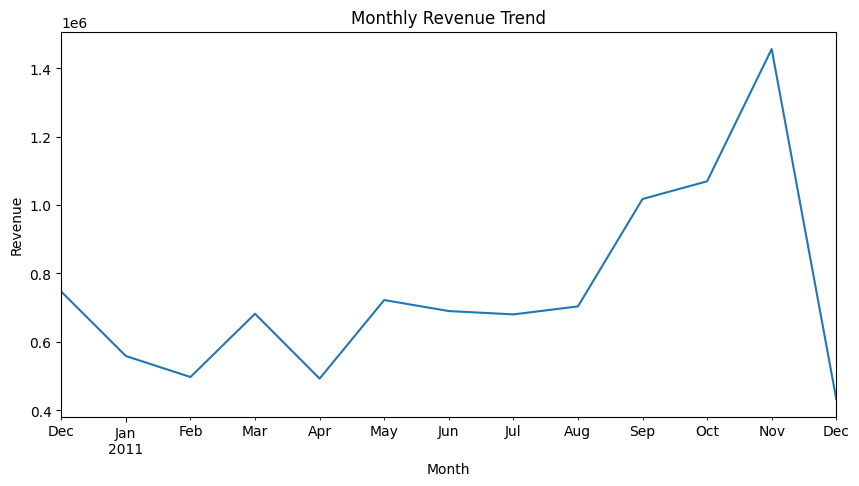

In [33]:
#revenue trend plot
monthly_revenue = df.groupby("Month")["Revenue"].sum()
monthly_revenue.plot(figsize = (10,5), title = "Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

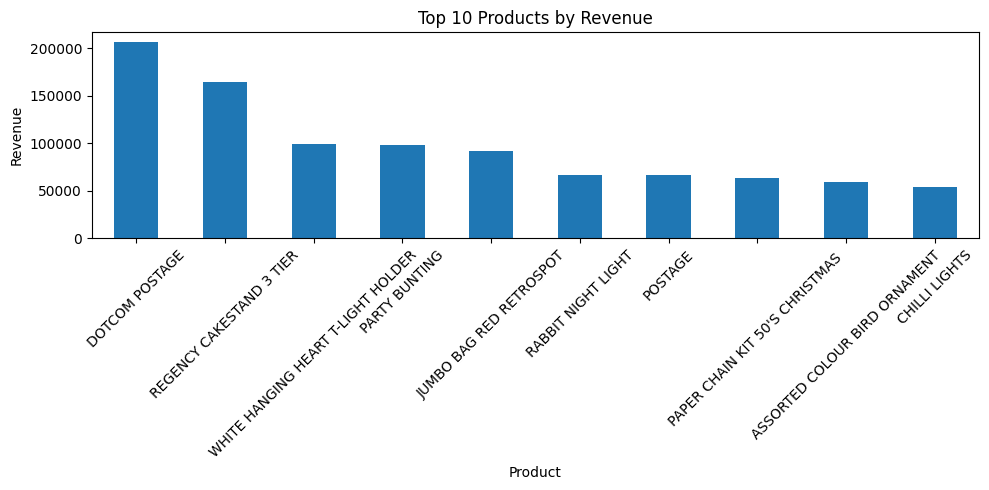

In [34]:
#top products plot
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending = False).head(10)
top_products.plot(kind = "bar", figsize = (10,5), title = "Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

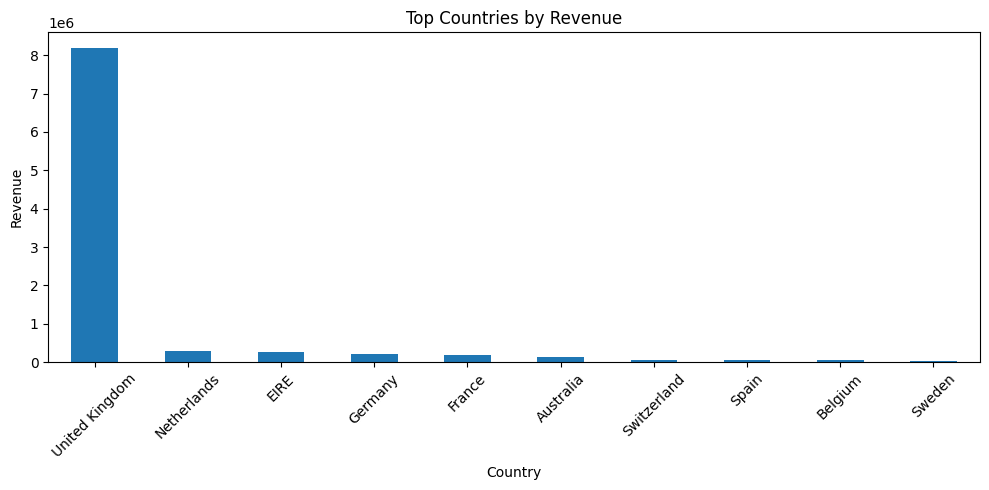

In [35]:
#country performance plot
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending = False)
country_revenue.head(10).plot(kind = 'bar', figsize = (10,5), title = "Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [36]:
#customer revenue
customer_revenue = (df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending = False))
customer_revenue.head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64

### 5. EXPORTING THE CLEAN DATA

In [37]:
df.shape #diplaying the shape and dimensions of the data

(534129, 14)

In [43]:
df.to_csv("clean_sales_data.csv", index = False) #exporting the data

#fixing customerID
df["CustomerID"] = df["CustomerID"].astype("Int64")

#fixing datetime properly
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

#fixing InvoiceNo consistency
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

#fixing Month properly
df["Month"] = df["InvoiceDate"].dt.month
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

#final check
print(df.dtypes)
print(df["TransactionType"].unique())

# Verify immediately
test = pd.read_csv("clean_sales_data.csv")
print(test.shape)

InvoiceNo                     str
StockCode                     str
Description                   str
Quantity                    int64
InvoiceDate        datetime64[us]
UnitPrice                 float64
CustomerID                  Int64
Country                       str
TransactionType               str
Revenue                   float64
Month                       int32
MonthName                     str
YearMonth                     str
Year                        int32
dtype: object
<StringArray>
['Purchase', 'Return']
Length: 2, dtype: str


C:\Users\Solar Dryer Computer\AppData\Local\Temp\ipykernel_10024\1792496553.py:21: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv("clean_sales_data.csv")


(534129, 14)


In [39]:
os.listdir()

['clean_sales_data.csv',
 'dim_customers.csv',
 'dim_date.csv',
 'dim_products.csv',
 'fact_sales.csv',
 'notebooks_TASK1(BSPA).ipynb',
 'TASK1(BSPA).ipynb']

### 6. Insights and recommendations

### 📈 6.1 Revenue Trends
- Revenue shows a strong upward trend toward the end of the year, peaking in November (~1.16M).
- There is a sharp drop in December (~518K) after the peak.

Insight: 

The business exhibits clear seasonality, with demand building up toward late-year peak periods (likely holiday-driven). The sudden drop in December suggests either post-peak slowdown or incomplete monthly data.

Recommendation:

- Capitalize on Q4 demand (Oct–Nov) with aggressive marketing and inventory planning
- Investigate December drop → determine if it's data cutoff or demand collapse
- Implement year-round demand smoothing strategies

### 🏆 6.2 Product Performance

- Top product: PAPER CRAFT, LITTLE BIRDIE (~168K revenue)
- Top 5 products contribute a significant portion of total revenue

Insight:

Revenue is concentrated among a small group of high-performing products, indicating limited diversification.

Risk:

Heavy reliance on a few products creates revenue vulnerability if demand shifts.

Recommendation:

- Increase promotion of top-performing products
- Analyze why these products succeed (price, demand, seasonality)
- Expand or replicate similar product lines to reduce dependency risk

### 🌍 6.3 Regional Performance

- United Kingdom dominates revenue (~7.3M) by a massive margin
- Next markets (Netherlands, EIRE, Germany, France) are significantly smaller

Insight:

The business is heavily dependent on a single geographic market (UK).

Risk:

Any disruption in the UK market (economic, regulatory, competition) would severely impact total revenue.

Recommendation:

- Expand operations and marketing in high-potential international markets
- Investigate barriers to growth in non-UK regions
- Diversify revenue streams geographically

### 👥 6.4 Customer Analysis

- Top customer (ID: 14646) generated ~280K revenue
- Top 5 customers contribute a substantial share of total revenue

Insight:

Revenue is highly concentrated among a small group of high-value customers.

Risk:

Loss of key customers would result in significant revenue decline.

Recommendation:

- Implement customer retention strategies (loyalty programs, personalized offers)
- Identify characteristics of high-value customers and target similar profiles
- Reduce dependency by broadening the customer base